In [332]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

# metrics

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import brier_score_loss

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#activations
from tensorflow.keras.activations import sigmoid
#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import TerminateOnNaN
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback

#preprocessing 
from tensorflow.keras.preprocessing import image
import sys
from copy import deepcopy
import kagglehub


In [333]:
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

In [334]:
path = os.path.join(os.getcwd(), 'DataSet', 'auto-mpg_1.csv')
df = pd.read_csv(path)

# Clean horsepower column
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["horsepower"])


#### Why we drop the dependent variable in multicollinearity analysis

- Multicollinearity is only about predictors.
It measures how strongly independent variables are correlated with each other.
- The dependent variable (Y) is not part of the calculation because collinearity among predictors affects the stability of regression coefficients, not the relationship with Y.
- If you include Y in the analysis, you’re mixing two different concepts: predictor redundancy vs. predictive strength. That’s why we drop Y when computing VIF or correlation matrices for multicollinearity.


PCA vs. VIF in relation to Y

PCA:

Purely unsupervised. It maximizes variance in X, not correlation with Y. Sometimes the components that explain most variance in X are not the ones most predictive of Y. That’s why PCA is used for dimensionality reduction, not for direct prediction.

VIF:

Formula doesn’t use Y directly. But in practice, you compute VIF on the predictors you’ve chosen for a regression model with Y. The context of Y matters (because you care about coefficient stability in that model), but the math itself is only about X’s.


In [335]:
# Select numerical variables
X_un_scale_df = df[["displacement","horsepower","weight","acceleration","cylinders"]]
mColumns = X_un_scale_df.columns.values.tolist()
# --- Standard Scaler ---
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_un_scale_df)
X_std_df = pd.DataFrame(X_std, columns=X_un_scale_df.columns)

# --- MinMax Scaler ---
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_un_scale_df)
X_mm_df = pd.DataFrame(X_mm, columns=X_un_scale_df.columns)

## Why We Need to Check for Multicollinearity in the Auto-MPG Dataset

#### 1. Background
The Auto-MPG dataset contains several predictor variables:
- Cylinders  
- Displacement  
- Horsepower  
- Weight  
- Acceleration  
- Model year  
- Origin  

Many of these variables are **highly correlated**. For example:
- `displacement`, `horsepower`, and `weight` often move together because larger engines tend to produce more horsepower and require heavier cars.  
- `cylinders` is strongly tied to `displacement` and `horsepower`.  
- `model year` is indirectly related to `mpg` because newer cars were designed to be more fuel efficient.

#### 2. What is Multicollinearity? and Why It Matters for Auto-MPG ?

Multicollinearity occurs when two or more predictor variables in a regression model are highly correlated.  
Inflated standard errors of coefficients, Unstable estimates (coefficients can change drastically with small data variations), Difficulty in interpreting the individual effect of each variable.

Since the dataset is often used to predict `mpg` (fuel efficiency), ignoring multicollinearity can cause:
- Misleading regression coefficients (e.g., displacement vs horsepower effects overlap)  
- Poor generalization to new data  
- Incorrect conclusions about which features truly drive fuel efficiency

#### Qus: How the multicollinearity create problem for linear regressions ?
 
In linear regression analysis parameter are the estimated by 

$\hat \beta = (X'X)^{-1} X'y$ ---- (i)

X'X is the square matrix and we are calculation inverse of square matrix. 

Now come to main point, Inverse matrix are Calculate by: 
Divide the adjoint matrix by the original determinant.

The formula for the inverse of a 2×2 matrix is:

$A^{-1}=\frac{1}{|A|}\cdot \mathrm{adj}(A)$ ; where |A| is the determinant.

You should focus on the determined part. for an example:

$A=\left[ \begin{matrix}a&b\\ c&d\end{matrix}\right] ,\quad |A|=ad-bc$

If the two columns of A are collinear (similar), then ad-bc\rightarrow 0.
This makes $|A|$ very small, and therefore $A^{-1}$ tends to $\infty$


Now from matrix A columns 1 and 2nd are similar or collinear then difference of product ad-bc have tendency to reach zero and $A^-1$ or ($(X'X)^-1$ in linear parameter estimations) tendency to approach $\infty$. 

#### Qus: So what happen if inverse parameter of square matrix $(X'X)^-1$ tends to $\infty$?

In regression, the variance of estimated coefficients is proportional to:

$Var(\hat {\beta })\propto (X'X)^{-1}$

If predictors are highly correlated, $X'X$ becomes nearly singular (determinant close to 0). This makes $(X'X)^{-1}$ unstable → variances of coefficients blow up.

Equations (1) become unstable. Coefficients become unstable (small changes in data cause large swings). Standard errors are inflated. Confidence intervals become very wide. Statistical significance tests (t-tests, p-values) become unreliable.

Remember that we have multiply transpose vector of X and make it square matrix. Because of  it is not possible to find a standard two-sided inverse for a non-square matrix. A standard inverse $A^{-1}$ is only defined for square matrices that are non-singular (having a non-zero determinant).


# Multicollinearity detections technique:

## 1. Variance Inflation Factor (VIF):

**Definition:**  

Variance Inflation Factor (VIF) is a statistical measure used to detect the presence and severity of **multicollinearity** in regression analysis. It quantifies how much the variance of a regression coefficient is inflated due to linear dependence among predictor variables.

#### Calculations Variance Inflation Factor (VIF):

For predictor $X_j$, the VIF is defined as:

$C_{jj}=\frac{1}{1-R_j^2}$

$C_{jj}$ → diagonal element of the covariance matrix $(X'X)^{-1}$. $R_j^2$ → the coefficient of determination when regressing predictor $X_j$ on all other predictors.

So:

$VIF_j=C_{jj}=\frac{1}{1-R_j^2}$

where $R_j^2$ is the coefficient of determination when regressing $X_j$ on all the other predictors.

If $R_j^2$ is close to 1, it means predictor $X_j$ is highly explained by other predictors → strong multicollinearity. As $R_j^2\rightarrow 1$, the denominator $(1-R_j^2)$ becomes very small → $VIF_j$ becomes very large. A **large VIF indicates that the variance of the coefficient estimate for $X_j$ is inflated due to correlation with other predictors.**

VIF measures how much the variance of the estimated coefficient $\hat \beta_j$ is inflated due to multicollinearity




#### how multicollinearity is diagnosed and deal with using VIF (Variance Inflation Factor) ?

#### Calculate  square root of the j‑th VIF

Qus: why we calculate square root of the j‑th VIF ?

Ans: The square root of the jth VIF indicates **how much longer the confidence interval** for the jth regression coefficient is because of multicollinearity. - The square root of the j‑th VIF gives the inflation factor of the standard error of $\hat {\beta }_j$.

$\sqrt{VIF_j}=\frac{\mathrm{SE\  with\  multicollinearity}}{\mathrm{SE\  without\  multicollinearity}}$

Please see another approch to understand the square root of the j‑th VIF

$\sqrt{VIF_j}=\sqrt{C_{jj}}=\frac{L_j}{L^*}$

Where:
- $VIF_j$ = Variance Inflation Factor for predictor $X_j$.
- $C_{jj}$ = diagonal element of the covariance matrix for coefficient $j$.
- $L_j$ = length of the confidence interval for coefficient $j$.
- $L^*$ = length of the confidence interval if predictors were orthogonal (uncorrelated)

#### length of Confidence Interval:

The confidence interval length for coefficient $j$ is:

$L_j=2\cdot \sqrt{C_{jj}\cdot \sigma ^2}\cdot t_{\alpha /2,n-p-1}$

In an orthogonal design (no multicollinearity), the interval length is:

$L^*=2\cdot \sigma \cdot t_{\alpha /2,n-p-1}$
- Therefore:
$\sqrt{VIF_j}=\frac{L_j}{L^*}$

$\sqrt{VIF_j}$ tells how much **longer the confidence interval for coefficient** $j$ is compared to the ideal case with no multicollinearity.

Take Example:
If $\sqrt{VIF_j}=2$, the confidence interval for $\beta _j$ is $twice$ as wide as it would be in an orthogonal design.

If $\sqrt{VIF_j}=5$, the interval is five times wider.

This directly links multicollinearity to loss of precision in estimating coefficients

#### Final conclusions:

Large $\sqrt{VIF_j}$ means your **coefficient estimates are unstable and less reliable**. Even if the predictor is theoretically important, high multicollinearity makes it hard to distinguish its unique effect. This is why **thresholds like VIF > 10 (or equivalently $\sqrt{VIF}>3.16$)** are **often used to flag problematic predictors**

- Interpretation:
    - VIF = 1–5 → Low correlation, safe.
    - VIF = 5–10 → Moderate correlation, caution.
    - VIF > 10 → High multicollinearity, problematic.

- Square root of VIF → tells you how much wider the confidence interval for $\hat \beta _j$ is compared to an orthogonal design (no correlation).



        feature     VIF_raw  VIF_standard_scaled  VIF_minmax_scaled
0  displacement   73.478856            19.535061          47.240658
1    horsepower   43.979332             8.916017          15.424389
2        weight  137.439120            10.430271          34.382682
3  acceleration   27.833437             2.609487           3.385731
4     cylinders  101.859772            10.630870          31.739118
=============================== interpret VIF values with standard scaled ==================
        feature  VIF_standard_scaled                        Interpretation
0  displacement            19.535061  High multicollinearity (Problematic)
1    horsepower             8.916017        Moderate correlation (Caution)
2        weight            10.430271  High multicollinearity (Problematic)
3  acceleration             2.609487                Low correlation (Safe)
4     cylinders            10.630870  High multicollinearity (Problematic)


=============================== Comparison of V

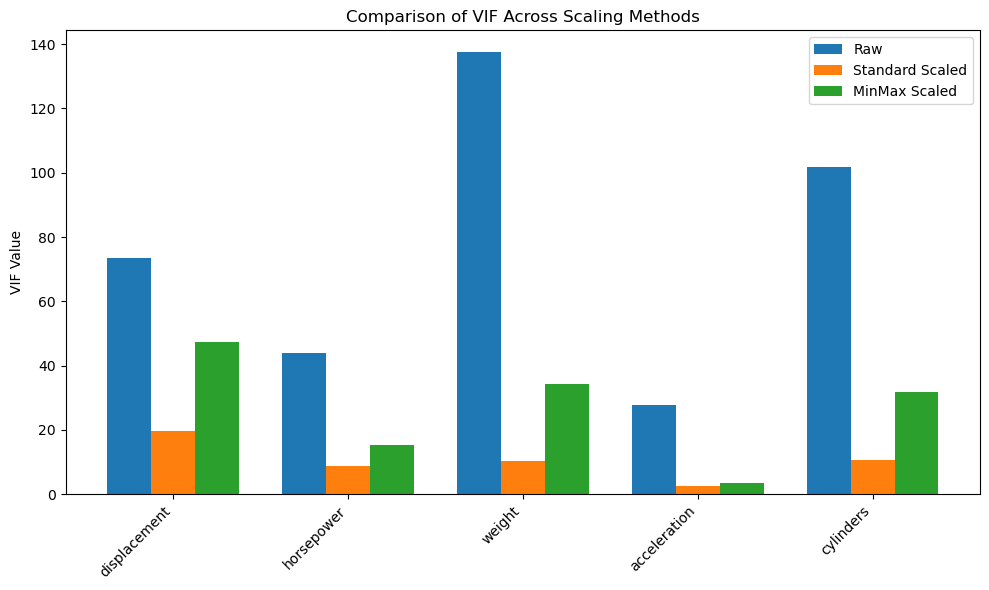

In [336]:
def compute_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["feature"] = dataframe.columns
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i) 
                       for i in range(dataframe.shape[1])]
    return vif_data

# Without scaling
vif_raw = compute_vif(X_un_scale_df)

# With standard scaling
vif_scaled_std = compute_vif(X_std_df)

# With min max scaling
vif_scaled_min_max = compute_vif(X_mm_df)


vif_combined = pd.DataFrame({
    "feature": vif_raw["feature"],
    "VIF_raw": vif_raw["VIF"],
    "VIF_standard_scaled": vif_scaled_std["VIF"],
    "VIF_minmax_scaled": vif_scaled_min_max["VIF"]
})

print(vif_combined)

# Function to interpret VIF values
def interpret_vif(vif_value):
    if vif_value < 5:
        return "Low correlation (Safe)"
    elif 5 <= vif_value <= 10:
        return "Moderate correlation (Caution)"
    else:
        return "High multicollinearity (Problematic)"

# Create new DataFrame with interpretations for VIF_standard_scaled
vif_interpretation = pd.DataFrame({
    "feature": vif_combined["feature"],
    "VIF_standard_scaled": vif_combined["VIF_standard_scaled"],
    "Interpretation": vif_combined["VIF_standard_scaled"].apply(interpret_vif)
})
tableDispFormatt('interpret VIF values with standard scaled')
print(vif_interpretation)

print('\n')
tableDispFormatt('Comparison of VIF Across Scaling and non-Scaling Methods')
# Plot VIF comparison
fig, ax = plt.subplots(figsize=(10,6))

features = vif_combined["feature"]
x = range(len(features))

ax.bar([i-0.25 for i in x], vif_combined["VIF_raw"], width=0.25, label="Raw")
ax.bar(x, vif_combined["VIF_standard_scaled"], width=0.25, label="Standard Scaled")
ax.bar([i+0.25 for i in x], vif_combined["VIF_minmax_scaled"], width=0.25, label="MinMax Scaled")

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_ylabel("VIF Value")
ax.set_title("Comparison of VIF Across Scaling Methods")
ax.legend()

plt.tight_layout()
plt.show()

The comparison of VIF values across raw, standardized, and min‑max scaled data shows that scaling dramatically reduces inflated multicollinearity measures. In the raw dataset, VIF values were excessively high due to differences in variable magnitudes. After applying StandardScaler, the VIF values dropped to stable and interpretable levels, making it the most effective approach for diagnosing multicollinearity. MinMaxScaler also reduced VIF values compared to raw data, but not as effectively as standardization. This confirms that scaling—especially standardization—is essential before applying VIF in datasets like Auto‑MPG to obtain reliable results.

## 2. Eigen vector address multi-collinearity:

#### Eigen vector how to address multi collinearity ?

Multicollinearity and Eigenvalues In regression, the correlation structure of predictors can be studied using the eigenvalues (characteristic roots) of the matrix X'X or the correlation matrix of predictors. Small eigenvalues (close to zero) indicate that some predictors are nearly linear combinations of others → this is multicollinearity. The smaller the eigenvalue, the stronger the dependency among predictors.


$\mathrm{Multicollinearity\  severity}\; \alpha \; \propto \frac{1}{\lambda }$\
$\lambda$  = eigenvalue of the predictor correlation matrix.

$\lambda$  is very small, then $\frac{1}{\lambda }$ becomes very large → strong multicollinearity.

#### Condition Number and Condition Indices in Eigenvalues:

When analyzing multicollinearity using eigenvalues of the predictor matrix $X'$X:

$\kappa =\frac{\lambda _{\mathrm{max}}}{\lambda _{\mathrm{min}}}$
- $\kappa$  = Condition Number
- $\lambda _{\mathrm{max}}$ = largest eigenvalue
- $\lambda _{\mathrm{min}}$ = smallest eigenvalue


In [337]:
# --- Functions ---
def cond_correlation(df):
    return np.linalg.cond(df.corr())

def cond_covariance(df):
    return np.linalg.cond(np.cov(df.T))

def cond_design(df):
    X = np.column_stack([np.ones(df.shape[0]), df.values])  # add intercept
    return np.linalg.cond(X)

def interpret_condition_number(value):
    if value < 10:
        return "Safe (Low correlation)"
    elif 10 <= value <= 30:
        return "Moderate correlation (Caution)"
    else:
        return "High multicollinearity (Problematic)"

# --- Compute condition numbers ---
results = []

for method, data in {
    "Raw (Unscaled)": X_un_scale_df,
    "Standard Scaled": X_std_df,
    "MinMax Scaled": X_mm_df
}.items():
    corr_val = cond_correlation(data)
    cov_val = cond_covariance(data)
    design_val = cond_design(data)

    results.append({
        "Scaling Method": method,
        "Correlation Matrix": corr_val,
        "Correlation Interpretation": interpret_condition_number(corr_val),
        "Covariance Matrix": cov_val,
        "Covariance Interpretation": interpret_condition_number(cov_val),
        "Design Matrix": design_val,
        "Design Interpretation": interpret_condition_number(design_val)
    })

# --- Create DataFrame ---
cond_summary = pd.DataFrame(results)

#print(cond_summary)

cond_summary = pd.DataFrame(results)

# --- Color-coded highlighting ---
def highlight_interpretation(val):
    if "Safe" in val:
        return "background-color: lightgreen"
    elif "Moderate" in val:
        return "background-color: khaki"
    elif "High" in val:
        return "background-color: lightcoral"
    return ""

styled_summary = cond_summary.style.map(highlight_interpretation, subset=[
    "Correlation Interpretation",
    "Covariance Interpretation",
    "Design Interpretation"
])

styled_summary


,Scaling Method,Correlation Matrix,Correlation Interpretation,Covariance Matrix,Covariance Interpretation,Design Matrix,Design Interpretation
0,Raw (Unscaled),111.504346,High multicollinearity (Problematic),2676285.521370,High multicollinearity (Problematic),38745.127738,High multicollinearity (Problematic)
1,Standard Scaled,111.504346,High multicollinearity (Problematic),111.504346,High multicollinearity (Problematic),10.559562,Moderate correlation (Caution)
2,MinMax Scaled,111.504346,High multicollinearity (Problematic),101.333011,High multicollinearity (Problematic),26.150221,Moderate correlation (Caution)


#### Difference between using correlation, covariance, and the design matrix for condition number analysis:

*Why the condition number from the correlation matrix is identical ?*

- A correlation matrix is scale‑invariant: it standardizes each variable by its variance before computing correlations.
- Whether you use raw values, StandardScaler, or MinMaxScaler, the correlation structure between variables remains the same.
- Because the correlation matrix doesn’t change with scaling, the condition number is identical across all scaling methods.
That’s why you saw the same value (~111.50) for raw, standardized, and min‑max scaled data.

*Covariance matrix and design matrix* condition numbers are the meaningful diagnostics: they show how scaling improves numerical stability and reduces multicollinearity. Among the methods, StandardScaler gives the most satisfactory results — condition numbers drop to safe levels, making regression analysis reliable.


This unified table makes it crystal clear:
- Correlation matrix → same across scaling, always problematic.
- Covariance matrix → scaling helps but still problematic.
- Design matrix → StandardScaler gives safe results, MinMaxScaler is cautionary, raw is problematic.


## 3. Principal Component Analysis (PCA) and Multicollinearity

Principal Component Analysis (PCA) can be viewed as a powerful technique to **address multicollinearity** in a dataset.  
Instead of working directly with the original, often correlated variables, PCA transforms them into a new set of **uncorrelated variables** called *principal components*.  

- Each principal component is a **linear combination** of the original variables.  
- The components are ordered by importance:  
  - The **first principal component** captures the maximum possible variance in the data.  
  - Subsequent components explain progressively smaller amounts of variance, while remaining orthogonal (uncorrelated) to the previous ones.  

By using principal components as predictors in regression models, we reduce redundancy among variables, stabilize coefficient estimates, and improve interpretability.  
This makes PCA especially useful when dealing with datasets like Auto‑MPG, where variables such as displacement, horsepower, and weight are highly correlated.

While we won't dive into the formal mathematical derivations of PCA here, we will walk through the step-by-step implementation to understand how it transforms our correlated features into principal components.

Step 1: Find the variance–covariance matrix of dataset: for an example

The variance–covariance matrix of the data is:

$\Sigma =\left[ \begin{matrix}2.879368&10.01&-1.80905\\ 10.01&199.7884&-5.64\\ -1.80905&-5.64&3.627658\end{matrix}\right]$ 

Step 2:The eigenvalues and eigenvectors of this matrix, arranged in decreasing order of eigenvalues, are:

- $\lambda _1=200.462, with\ eigenvector\ a_1=(0.0508,0.9983,-0.0291)$
- $\lambda _2=4.532, with eigenvector a_2=(-0.5737,0.0530,0.8173)$
- $\lambda _3=1.301, with eigenvector a_3=(0.8175,-0.0249,0.5754)$

Step 3:The principal components are linear combinations of the original variables $x_1,x_2,x_3$:

$z_1=0.0508x_1+0.9983x_2-0.0291x_3$

$z_2=-0.5737x_1+0.0530x_2+0.8173x_3$

$z_3=0.8175x_1-0.0249x_2+0.5754x_3$

where $z_1,z_2,z_3$ are the principal component.

*Note: The variance of principal components will be eigenvalues*

The variance of the principal components is equal to the eigenvalues:

$\mathrm{Var}(z_1)=200.462,\quad \mathrm{Var}(z_2)=4.532,\quad \mathrm{Var}(z_3)=1.301$

The total variation explained by the principal components is:

$\lambda _1+\lambda _2+\lambda _3=200.462+4.532+1.301=206.295$

Step 4: Calculate proportion of total variation accounted for by the principal component

The proportion of total variation accounted for by the first principal component is

$\frac{\lambda _1}{\lambda _1+\lambda _2+\lambda _3}=\frac{200.462}{206.295}=0.9717\quad \mathrm{of\  the\  total\  variance}$

The proportion of total variance explained by the first two principal components is:

$\frac{\lambda _1+\lambda _2}{\lambda _1+\lambda _2+\lambda _3}=\frac{204.994}{206.295}=0.9937\quad \mathrm{of\  the\  total\  variance}$

Hence, in further analysis, the first one or two principal components ($Z_1$ and $Z_2$) can effectively replace the original three variables while sacrificing only a negligible amount of information about the total variation in the system. The loss of information is:
$1-0.9937=0.0063\approx 0.63\%$
This means that by excluding the third component, we retain over 99% of the variance. Such a reduction demonstrates the essence of dimensionality reduction: simplifying the dataset by removing redundant variables while preserving nearly all of the meaningful information.

Step 5: Finally calculate your PC component:

Let from your Dataset variables are

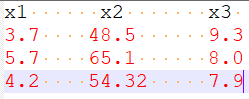

On the basis of given data your corresponding principal component are the

For ($x_1,x_2,x_3$)=(3.7,48.5,9.3):

- $z_1$=0.0508(3.7)+0.9983(48.5)-0.0291(9.3) = 0.18796+48.44155-0.27063 $\approx$ 48.36
- $z_2$=-0.5737(3.7)+0.0530(48.5)+0.8173(9.3) = -2.12269+2.5705+7.60089 $\approx$ 8.05
- $z_3$=0.8175(3.7)-0.0249(48.5)+0.5754(9.3) = 3.025-1.20865+5.35422 $\approx$ 7.17

For ($x_1,x_2,x_3$)=(5.7,65.1,8.0):

- $z_1$=0.0508(5.7)+0.9983(65.1)-0.0291(8.0) = 0.28956+64.98933-0.2328 $\approx$ 65.05
- $z_2$=-0.5737(5.7)+0.0530(65.1)+0.8173(8.0) = -3.269+3.4503+6.5384 $\approx$ 6.72
- $z_3$=0.8175(5.7)-0.0249(65.1)+0.5754(8.0) = 4.660-1.620+4.603 $\approx$ 7.64

For ($x_1,x_2,x_3$)=(4.2,54.32,7.9):

- $z_1$=0.0508(4.2)+0.9983(54.32)-0.0291(7.9) = 0.21336+54.22714-0.22989 $\approx$ 54.21
- $z_2$=-0.5737(4.2)+0.0530(54.32)+0.8173(7.9) = -2.40954+2.8790+6.46067 $\approx$ 6.93
- $z_3$=0.8175(4.2)-0.0249(54.32)+0.5754(7.9) = 3.434+-1.353+4.544 $\approx$ 6.63

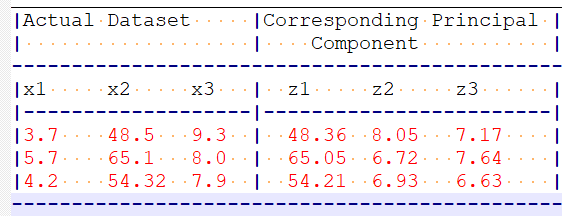



The Auto-MPG dataset contains the following variables:

mpg, cylinders, displacement, horsepower, weight, acceleration, model year, origin, and car name.

Among these, the categorical variables are model year, origin, and car name. For the investigation of multicollinearity, I will focus only on the numerical variables.
To detect multicollinearity in the dataset, I plan to use three statistical techniques:
- Variance Inflation Factor (VIF)
- Principal Component Analysis (PCA)
- Condition Number of the Eigenvalue Matrix
It is important to note that multicollinearity can be strongly influenced by whether the data is scaled or unscaled. Therefore, part of the analysis will involve comparing the detection of multicollinearity with scaling and without scaling, to understand how scaling affects the results.

In [338]:
# Step by step PCA analysis
# return ProjectedData,PCA,PCA_variance,X_mean
def pca_step_by_step(X_centered, n_components):
    # Step 1: Standardize the data     
    # Standardize the data (mean=0, variance=1)        
    # Step 2: Compute the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)
    
    # Step 3: Compute the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Step 4: Sort the eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    # Step 5: Select the first n_components principle component eigenvectors
    PCs = sorted_eigenvectors[:, :n_components]*-1    
    # Step 6: Projected Data
    X_principal_component = np.dot(X_centered, PCs)
    # Step 7: Return the projected data, PCs, eigenvalues, and mean
    return X_principal_component, PCs, sorted_eigenvalues[:n_components]

# PCA by using numpy svd
def pca_from_svd(X_centered):
    # Step 1: Standardize the data
    #print('pca_from_svd is set to True, standardizing the data')
       
    # Step 2: Perform Singular Value Decomposition (SVD)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    # U: left singular vectors
    # S: singular values
    # Vt: right singular vectors (principal component directions)
    # Step 3: Select the first n_components principal components
    # Eigenvalues from singular values
    eigenvalues = (S**2) / (X_centered.shape[0] - 1)
    # Explained variance ratio
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    Cumulative_variance      = np.cumsum(explained_variance_ratio)
    PCs = Vt.T
    # Transform data (scores);Project the data onto the principal components
    X_pca = np.dot(X_centered, PCs)
    
    return X_pca, PCs, explained_variance_ratio, Cumulative_variance

# PCA by using sklearn
def pca_from_PCA_scaled(X_scaled, columns, n_components: int = 2):
    """
    Apply PCA to already scaled data.
    
    Parameters:
        X_scaled (ndarray): Pre-scaled numeric data (e.g., from StandardScaler).
        columns (list): Names of the original features (for loadings).
        n_components (int): Number of principal components to compute.
    
    Returns:
        explained_variance_ratio (array): Variance explained by each PC.
        components (pd.DataFrame): PCA loadings (linear combinations).
        X_pca (ndarray): Transformed data in PC space.
    """
    # Apply PCA directly
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # Variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_

    # Components (loadings)
    components = pd.DataFrame(
        pca.components_,
        columns=columns,
        index=[f"PC{i+1}" for i in range(n_components)]
    )

    return explained_variance_ratio, components, X_pca

def plot_variance_ratio(variance_ratio,title_str):
    """
    Plot explained variance ratio for PCA components with annotations.
    """
    n_components = len(variance_ratio)
    x = np.arange(1, n_components + 1)

    plt.figure(figsize=(8,5))
    bars = plt.bar(x, variance_ratio, color="orange", edgecolor="black")

    # Add cumulative variance line
    plt.plot(x, np.cumsum(variance_ratio), marker="o", color="red", label="Cumulative Variance")

    # Annotate each bar with its value
    for bar, val in zip(bars, variance_ratio):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=9)

    plt.xticks(x, [f"PC{i}" for i in x])
    plt.ylabel("Explained Variance Ratio")
    plt.xlabel("Principal Components")
    plt.title(f"Explained Variance Ratio by {title_str}")
    plt.legend()
    plt.tight_layout()
    plt.show()

=============================== pca apply min-max scaler ===================================
Explained Variance Ratio: [0.88064951 0.07085767 0.03013616 0.00966601 0.00869065]

PCA Components (loadings):
      displacement  horsepower    weight  acceleration  cylinders
PC1      0.503132    0.365320  0.431056     -0.180338   0.628545
PC2      0.057003   -0.350971  0.258604      0.868185   0.230104
PC3     -0.064224   -0.445979 -0.578460     -0.177725   0.656335
PC4     -0.214527    0.736721 -0.465543      0.403270   0.178503
PC5      0.832744   -0.041302 -0.442683      0.139711  -0.298906


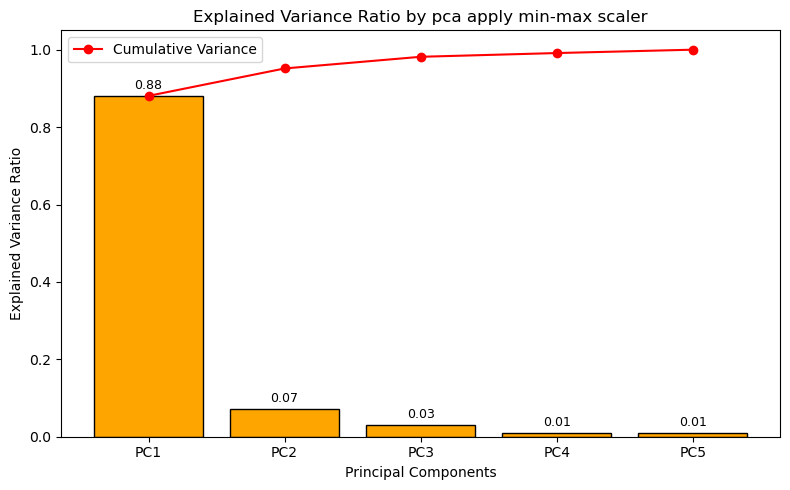

=============================== pca apply standerd scaler ==================================
Explained Variance Ratio: [0.81437196 0.13877225 0.02669861 0.01285368 0.0073035 ]

PCA Components (loadings):
      displacement  horsepower    weight  acceleration  cylinders
PC1      0.482404    0.473844  0.461790     -0.331379   0.468717
PC2      0.178630   -0.119989  0.345286      0.885736   0.223479
PC3      0.187640   -0.627571 -0.334497     -0.158656   0.658700
PC4     -0.021241   -0.593599  0.703244     -0.282071  -0.270319
PC5      0.836491   -0.121940 -0.247158      0.030387  -0.472655


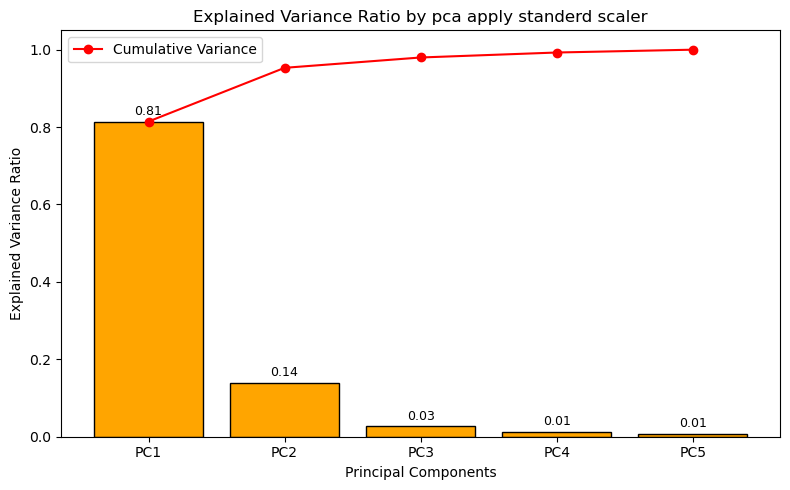

=============================== pca apply un-scaled data ===================================
Explained Variance Ratio: [9.97578746e-01 2.06165051e-03 3.55273905e-04 3.95643084e-06
 3.72747503e-07]

PCA Components (loadings):
      displacement  horsepower    weight  acceleration  cylinders
PC1      0.114341    0.038967  0.992674     -0.001353   0.001793
PC2      0.946116    0.298150 -0.120754     -0.034828   0.013330
PC3     -0.302440    0.950006 -0.002548     -0.077196  -0.007288
PC4      0.010042    0.084016 -0.003067      0.996269  -0.016686
PC5     -0.014857    0.004283 -0.000240      0.016532   0.999744


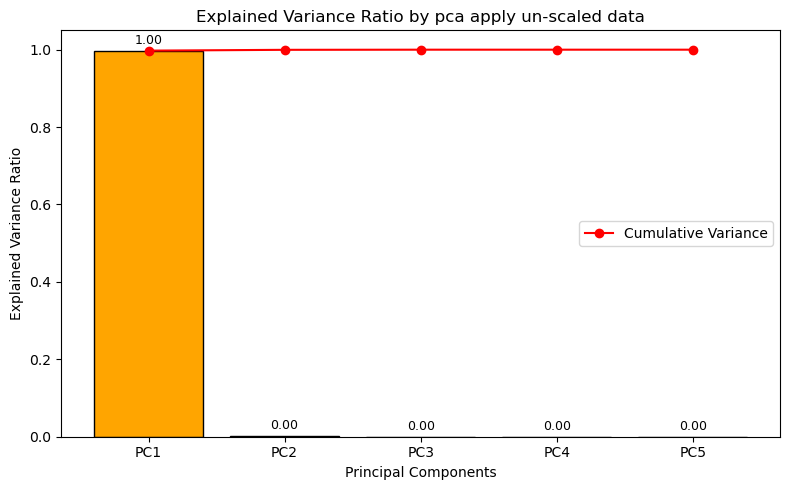

In [339]:


# --- Example usage ---
# Assume X_scaled is already created using StandardScaler
# and df is your original DataFrame

variance_ratio, pca_components, X_pca = pca_from_PCA_scaled(X_scaled = X_mm_df,
            columns = mColumns, n_components=X_mm_df.shape[1])
tableDispFormatt('pca apply min-max scaler')
print("Explained Variance Ratio:", variance_ratio)
print("\nPCA Components (loadings):\n", pca_components)
plot_variance_ratio(variance_ratio,'pca apply min-max scaler')
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])

variance_ratio, pca_components, X_pca = pca_from_PCA_scaled(X_scaled = X_std_df,
            columns = mColumns, n_components=X_std_df.shape[1])
tableDispFormatt('pca apply standerd scaler')
print("Explained Variance Ratio:", variance_ratio)
print("\nPCA Components (loadings):\n", pca_components)
plot_variance_ratio(variance_ratio,'pca apply standerd scaler')
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])
variance_ratio, pca_components, X_pca = pca_from_PCA_scaled(X_scaled = X_un_scale_df,
            columns = mColumns, n_components=X_un_scale_df.shape[1])
tableDispFormatt('pca apply un-scaled data')
print("Explained Variance Ratio:", variance_ratio)
print("\nPCA Components (loadings):\n", pca_components)
plot_variance_ratio(variance_ratio,'pca apply un-scaled data')
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])

#### Min–Max Scaler

- PC1 explains ~88% of the variance, with the remaining components contributing very little.
- This indicates one dominant axis of variation, but the distribution is slightly skewed because Min–Max scaling compresses values into [0,1] without equalizing variance.
- Result: Good, but not optimal — later PCs don’t capture meaningful structure.

#### Standard Scaler
- PC1 explains ~81%, PC2 ~14%, PC3 ~3%, and the rest negligible.
- This is the most balanced outcome: variance is spread across multiple components, showing that PCA is capturing meaningful multidimensional structure.
- Result: Best (perfect) result — StandardScaler equalizes variance across features, so PCA can correctly identify directions of maximum variance.

#### Unscaled Data
- PC1 explains ~100% of the variance, all others are ~0.
- This happens because features with larger numeric ranges dominate the covariance matrix.
- PCA is essentially “blind” to smaller‑scale variables, collapsing everything into one axis.
- Result: Misleading — PCA fails to capture the true structure.


#### PCA is sensitive to scaling.
Because PCA relies on variance and covariance, features measured on larger scales dominate the principal components if you don’t scale.
#### Scaling is necessary for PCA.
StandardScaler is generally the best choice because it standardizes each feature to zero mean and unit variance, ensuring all variables contribute equally to the analysis. The Standard Scaler result is the most reliable: it distributes variance across multiple components, avoids domination by a single variable, and reveals the underlying structure of the dataset

Standard Scaler gives the most trustworthy PCA: variance is distributed across PCs, showing real multidimensional structure. Min–Max Scaler is acceptable but less balanced. Unscaled data is misleading: PCA collapses everything into one axis because large‑scale variables dominate.

This demonstrates that PCA is sensitive to scaling. Without scaling, PCA ignores smaller‑scale variables. With proper scaling (especially StandardScaler), PCA reveals the true underlying structure.



## Final Conclusions from PCA (Standard Scaler):

Using the Standard Scaler, the principal component analysis shows:
- PC1 accounts for 81% of the total variation.
- PC2 accounts for 14%.
- PC3 accounts for 3%.

Together, PC1 + PC2 + PC3 explain 98% of the total variation in the dataset. This means that nearly all of the information is captured by the first three components, and the remaining components (PC4, PC5, etc.) contribute negligibly. Dropping them results in only a minimal loss of information.
In the Auto MPG dataset, the first three principal components are strongly associated with displacement, horsepower, and weight. These variables alone capture about 98% of the information related to fuel consumption, making them the dominant drivers of variation in the dataset.

PCA with Standard Scaler distributes variance meaningfully across multiple components. The first three PCs are sufficient to represent the dataset with minimal information loss. This highlights how PCA can reduce dimensionality while preserving nearly all of the explanatory power of the original variables.